🔹 Starting CVRPTW Log Parsing from: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\4_CVRPTW_dual_bounds_and_models\Solve_CVRPTW_time_limit\CVRPTW_EA_dual_bound_solver_logs
   Found 10 log files.

📊 Aggregating Results...
   ✅ Saved aggregated data to CVRPTW_EA_dual_bound_Parsing_Expansion_Limit_Results\CVRPTW_Average_Gaps_vs_Expansion.csv


C:\Users\ACER\AppData\Local\Temp\ipykernel_5072\913094062.py:210: RuntimeWarning: Mean of empty slice
  mean_gaps = np.nanmean(gap_matrix, axis=0)


   ✅ Saved plot to CVRPTW_EA_dual_bound_Parsing_Expansion_Limit_Results


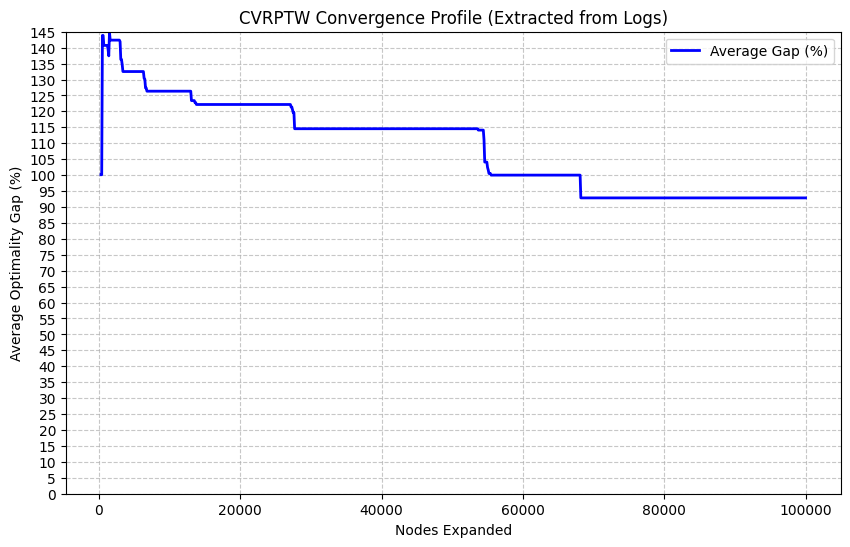

In [4]:
import pandas as pd
import numpy as np
import os
import re
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ CONFIGURATION
# ==========================================
# 1. Input Directories
LOG_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\4_CVRPTW_dual_bounds_and_models\Solve_CVRPTW_time_limit\CVRPTW_EA_dual_bound_solver_logs"
REF_RESULTS_CSV = "CVRPTW_single_dual_bound_selected_results_1800s_lim.csv"

# 2. Output Directory
OUTPUT_FOLDER = "CVRPTW_EA_dual_bound_Parsing_Expansion_Limit_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 3. Settings
NODE_EXPANSION_LIMIT = 100_000 
SAMPLE_STEP = 100 

# ==========================================
# 🧩 HELPER FUNCTIONS
# ==========================================
def parse_solver_log(file_path):
    """
    Reads log line-by-line. Tracks current best cost.
    Records history points for BOTH 'New primal bound' and 'Searched with beam size'.
    """
    raw_history = []
    current_best_cost = float('inf')
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                
                # 1. Check for New Primal Bound (Update State)
                match_primal = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
                if match_primal:
                    cost = float(match_primal.group(1))
                    expanded = int(match_primal.group(2))
                    
                    current_best_cost = cost
                    raw_history.append((expanded, cost))
                    
                    if expanded > NODE_EXPANSION_LIMIT:
                        break
                    continue

                # 2. Check for Beam Search Progress (Record State)
                match_beam = re.search(r"Searched with beam size:.*expanded:\s*(\d+)", line)
                if match_beam:
                    expanded = int(match_beam.group(1))
                    raw_history.append((expanded, current_best_cost))
                    
                    if expanded > NODE_EXPANSION_LIMIT:
                        break
                        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    
    # --- CLEANING STEP ---
    # Sort and remove duplicates by keeping the BEST cost for any given expansion count
    raw_history.sort(key=lambda x: x[0])
    
    cleaned_history = []
    for expanded, cost in raw_history:
        if not cleaned_history:
            cleaned_history.append((expanded, cost))
        else:
            last_expanded, last_cost = cleaned_history[-1]
            if expanded == last_expanded:
                cleaned_history[-1] = (expanded, min(cost, last_cost))
            else:
                cleaned_history.append((expanded, cost))
                
    return cleaned_history

def calculate_dense_gaps(history, optimal_cost, limit):
    """
    Generates a dense gap array using SAMPLE_STEP.
    - Leaves gap as NaN if no solution found yet.
    - Cuts off data (NaN) if solver stopped early (cutoff logic).
    """
    max_steps = limit // SAMPLE_STEP
    dense_gaps = np.full(max_steps, np.nan)

    if not history: return dense_gaps

    current_cost = float('inf')
    hist_idx = 0
    
    # Get the last recorded expansion point to handle cutoffs
    last_real_expansion = history[-1][0]
    
    for i in range(max_steps):
        current_node_count = (i + 1) * SAMPLE_STEP
        
        # CUTOFF LOGIC: Stop filling if we exceed the solver's actual history
        if current_node_count > last_real_expansion:
            break
        
        # Advance through history
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            val = history[hist_idx][1]
            if val < current_cost:
                current_cost = val
            hist_idx += 1
            
        if current_cost == float('inf'):
            dense_gaps[i] = np.nan # Keep as NaN
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            dense_gaps[i] = gap
        
    return dense_gaps

# ==========================================
# 🚀 MAIN EXECUTION
# ==========================================
def process_results():
    print(f"🔹 Starting CVRPTW Log Parsing from: {LOG_DIR}")
    
    # 1. Load BKS Reference
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing: {REF_RESULTS_CSV}")
        return
    
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    
    # Determine cost column
    if 'Best Known Cost' in df_ref.columns:
        cost_col = 'Best Known Cost'
    elif 'Cost' in df_ref.columns:
        cost_col = 'Cost'
    else:
        print("❌ Could not find 'Cost' or 'Best Known Cost' column in CSV.")
        return

    # Map: "instance_name" -> optimal_cost
    # Store both with and without .txt extension for easier matching
    bks_map = {}
    for _, row in df_ref.iterrows():
        raw_name = str(row['Instance']).strip()
        cost = float(row[cost_col])
        
        # Add variation 1: Exact match from CSV
        bks_map[raw_name] = cost
        
        # Add variation 2: Without .txt (if present)
        clean_name = raw_name.replace(".txt", "").replace(".vrp", "")
        bks_map[clean_name] = cost

    # 2. Find Log Files
    log_files = glob.glob(os.path.join(LOG_DIR, "solver_log_*.txt"))
    print(f"   Found {len(log_files)} log files.")
    
    all_dense_gaps = []

    for log_path in log_files:
        filename = os.path.basename(log_path)
        # Standard clean: "solver_log_C101.txt" -> "C101"
        name_clean = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        # Try matching
        if name_clean in bks_map:
            opt_cost = bks_map[name_clean]
        else:
            # Try fuzzy match if exact key fails (e.g. C1_2_1 vs C1_2_1.txt)
            found_key = None
            for k in bks_map:
                if k == name_clean or k in name_clean or name_clean in k:
                    # Prioritize exact start match for H&G instances like "C1_2_1" vs "C1_2_10"
                    # "C1_2_1" is in "C1_2_10", so simplistic 'in' check is dangerous.
                    # Instead, we check exact equality after stripping extensions
                    found_key = k
                    break
            
            if found_key:
                opt_cost = bks_map[found_key]
            else:
                # print(f"⚠️ Skipping {name_clean}: No BKS found.")
                continue

        # Parse & Calculate
        history = parse_solver_log(log_path)
        if history:
            dense_gaps = calculate_dense_gaps(history, opt_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # Save Individual Profile
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP),
                'Gap_Percent': dense_gaps
            })
            df_hist.to_csv(os.path.join(OUTPUT_FOLDER, f"gap_profile_{name_clean}.csv"), index=False)

    # 3. Aggregation & Plotting
    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        gap_matrix = np.vstack(all_dense_gaps)
        
        # Calculate Mean (ignoring NaNs)
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        x_axis = np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP)
        
        # Save Aggregate Data
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_FOLDER, "CVRPTW_Average_Gaps_vs_Expansion.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        # Plot
        plt.figure(figsize=(10, 6))
        
        # Only plot valid data
        valid_mask = ~np.isnan(mean_gaps)
        if np.any(valid_mask):
            plt.plot(x_axis[valid_mask], mean_gaps[valid_mask], label='Average Gap (%)', color='blue', linewidth=2)
            
            # 5-Step Y-Axis Logic
            max_y = np.max(mean_gaps[valid_mask])
            upper_limit = math.ceil(max_y / 5) * 5
            
            plt.yticks(np.arange(0, upper_limit + 5, 5))
            plt.ylim(0, upper_limit)
        else:
            print("⚠️ No valid data points to plot.")

        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title('CVRPTW Convergence Profile (Extracted from Logs)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        plot_path = os.path.join(OUTPUT_FOLDER, "convergence_plot.png")
        plt.savefig(plot_path)
        print(f"   ✅ Saved plot to {OUTPUT_FOLDER}")
        plt.show() 
        
    else:
        print("\n⚠️ No valid data extracted.")

if __name__ == "__main__":
    process_results()